Stored patterns : 


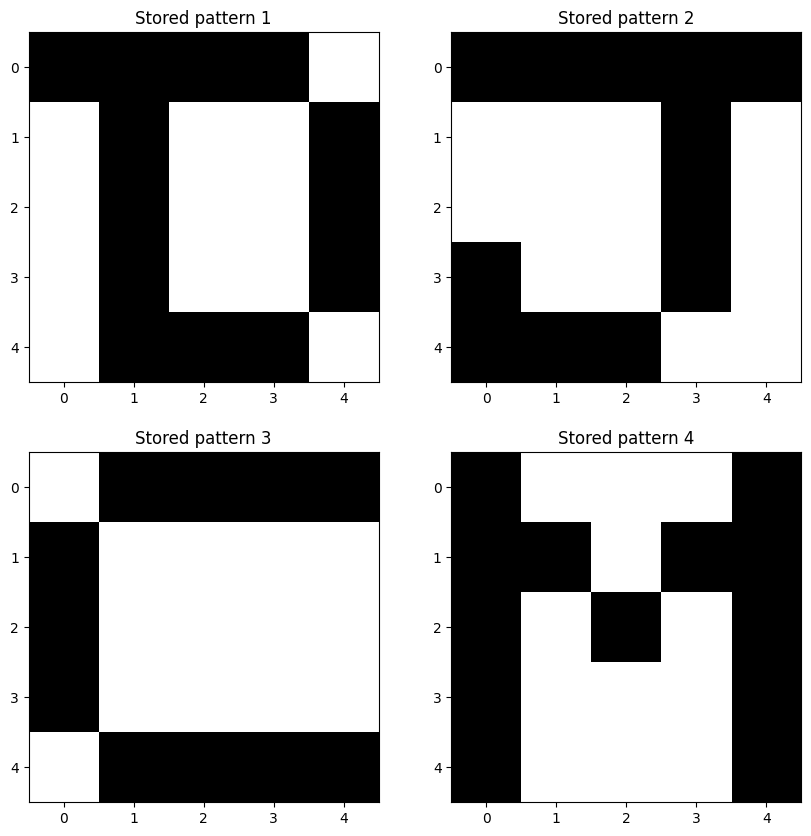

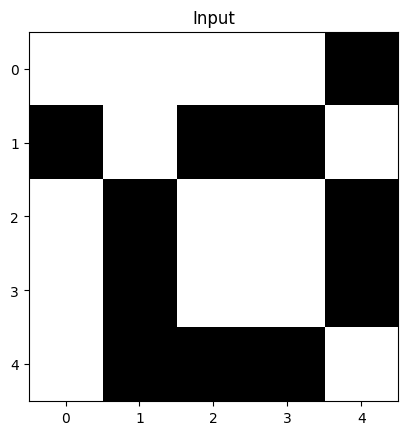

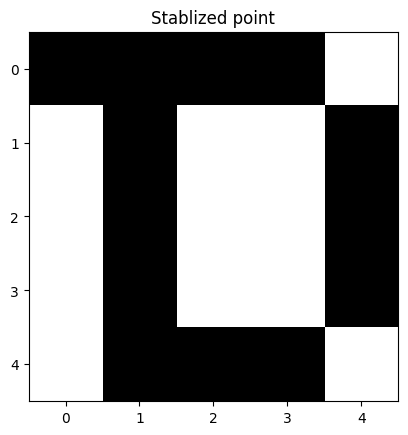

Tolerable error for stored pattern 1: 0 bits
Tolerable error for stored pattern 2: 13 bits
Tolerable error for stored pattern 3: 12 bits
Tolerable error for stored pattern 4: 16 bits


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def hamming_distance(pattern1, pattern2):
    return np.sum(pattern1 != pattern2)

X = np.array([[1, 1, 1, 1, -1, -1, 1, -1, -1, 1, -1, 1, -1, -1, 1, -1, 1, -1, -1, 1, -1, 1, 1, 1, -1],
              [1, 1, 1, 1, 1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, 1, -1, -1, 1, -1, 1, 1, 1, -1, -1],
              [-1, 1, 1, 1, 1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, 1, -1, -1, -1, -1, -1, 1, 1, 1, 1],
              [1, -1, -1, -1, 1, 1, 1, -1, 1, 1, 1, -1, 1, -1, 1, 1, -1, -1, -1, 1, 1, -1, -1, -1, 1]])

W = np.dot(X.T, X)
np.fill_diagonal(W, 0)
W = W.astype(float) / X.shape[0]

x = X[0].copy()
x[0:10] *= -1

print('Stored patterns : ')

plt.figure(figsize=(10, 10))
for i in range(len(X)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(-X[i].reshape(5, 5), cmap='gray')
    plt.title(f'Stored pattern {i+1}')

plt.show()

plt.imshow(-x.reshape(5, 5), cmap='gray')
plt.title('Input')
plt.show()

y = x.copy()
err_y = 10
iterations = 0
while err_y > 1:
    yp = np.sign(np.dot(W, y))
    err_y = np.linalg.norm(yp - y)
    y = yp.copy()
    iterations += 1

plt.imshow(-y.reshape(5, 5), cmap='gray')
plt.title('Stablized point')
plt.show()

for i, pattern in enumerate(X):
    dist = hamming_distance(pattern, y)
    print(f'Tolerable error for stored pattern {i+1}: {dist} bits')


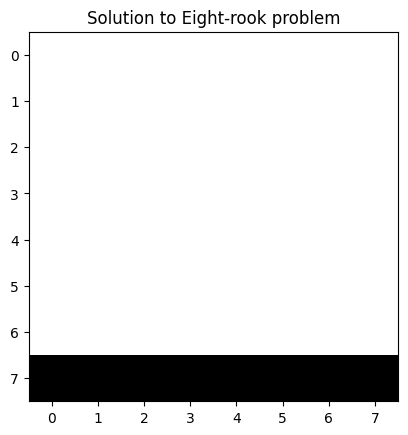

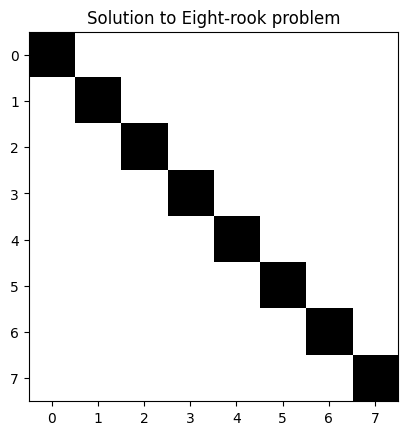

In [2]:
def energy(x, W, theta):
    return -0.5 * np.dot(x.T, np.dot(W, x)) + np.dot(theta, x)

def update_async(x, W, theta):
    for i in range(len(x)):
        u = np.dot(W[i], x) - theta[i]
        x[i] = 1 if u >= 0 else 0
    return x

def plot_chessboard(x):
    plt.imshow(x.reshape(8, 8), cmap='binary')
    plt.title('Solution to Eight-rook problem')
    plt.show()

W = np.zeros((64, 64))

for i in range(8):
    for j in range(8):
        for k in range(8):
            W[i*8 + j, i*8 + k] = -2  
            W[i*8 + j, k*8 + j] = -2  


np.fill_diagonal(W, 0)

theta = -np.ones(64)
x = np.zeros(64, dtype=int)
x[56:64] = 1
plot_chessboard(x)

max_iterations = 1000
for _ in range(max_iterations):
    x_new = update_async(x.copy(), W, theta)
    if energy(x_new, W, theta) > energy(x, W, theta):
        break
    x = x_new

plot_chessboard(x)

[[5.93932154 7.4367043 ]
 [6.42487038 5.90394865]
 [4.81289319 6.81304702]
 [4.9382849  9.02595701]
 [9.67296484 4.45097367]
 [8.12552534 5.76005428]
 [6.11240105 9.33036974]
 [1.63932452 1.7841637 ]
 [1.18196558 8.49357861]
 [8.00341076 8.83010933]]


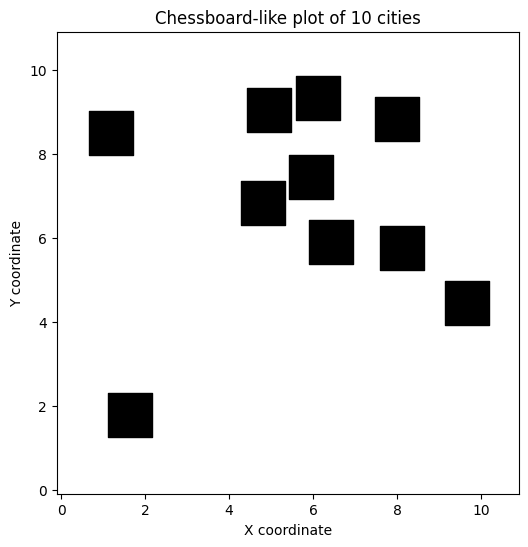

In [90]:
def plot_chessboard_cities(cities):
    plt.figure(figsize=(6, 6))
    for i in range(len(cities)):
            plt.scatter(cities[i, 0], cities[i, 1], color='black', s=1000, marker='s')
    plt.xlim(-0.1, 10.9)
    plt.ylim(-0.1, 10.9)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title('Chessboard-like plot of 10 cities')
    plt.xlabel('X coordinate')
    plt.ylabel('Y coordinate')
    plt.show()


np.random.seed(0)  
num_cities = 10
cities = np.random.uniform(1, 10, size=(num_cities, 2))
print(cities)


distances = np.zeros((num_cities, num_cities))
for i in range(num_cities):
    for j in range(i + 1, num_cities):
        distances[i, j] = np.linalg.norm(cities[i] - cities[j])
        distances[j, i] = distances[i, j] 


N = num_cities
W = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            W[i, j] = -distances[i, j]  
        else:
            W[i, j] = 0  


theta = -np.ones(N) 

x = np.zeros(N)
x[9] = 1

max_iterations = 1000
for _ in range(max_iterations):
    x_new = update_async(x.copy(), W, theta)
    if np.array_equal(x, x_new):
        break
    x = x_new

plot_chessboard_cities(cities)